In [1]:
!pip install econml

In [4]:
!pip install econml

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

# =====================================================
# Load Dataset
# =====================================================

df = pd.read_csv("/Users/ameypatil/Desktop/Tata Power/data/2024 data/with socio/monsoon_2024.csv")

df = df.dropna().reset_index(drop=True)

# =====================================================
# Outcome
# =====================================================

Y = df["wdLoad"].values

# =====================================================
# Treatments
# Temperature and Relative Humidity
# =====================================================

T = df[
    [
        "temp",
        "rh"
    ]
].values

# =====================================================
# Confounders / Adjustment Variables
# =====================================================

X = df[
    [
        "hour",
        "weekend",
        "holiday",
        "festival",
        "office_hours"
    ]
].values

# =====================================================
# Causal Forest
# =====================================================

model = CausalForestDML(

    model_y=RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),

    model_t=MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=300,
            random_state=42
        )
    ),

    n_estimators=500,

    min_samples_leaf=10,

    random_state=42
)

# =====================================================
# Train Model
# =====================================================

model.fit(
    Y,
    T,
    X=X
)

# =====================================================
# Conditional Marginal Effects
# =====================================================

effects = model.const_marginal_effect(X)

temp_effect = effects[:, 0]
rh_effect = effects[:, 1]

# =====================================================
# Average Marginal Effect
# =====================================================

ate_temp = np.mean(temp_effect)
ate_rh = np.mean(rh_effect)

print("\n========== MONSOON WEATHER EFFECTS ==========")

print("Average Marginal Effect (Temperature → Load):",
      ate_temp)

print("Average Marginal Effect (Humidity → Load):",
      ate_rh)

# =====================================================
# Treatment Statistics
# =====================================================

print("\n========== TREATMENT STATISTICS ==========")

print("Temperature range:",
      df["temp"].min(),
      "to",
      df["temp"].max())

print("Humidity range:",
      df["rh"].min(),
      "to",
      df["rh"].max())

print("\nOffice Hours distribution:")
print(df["office_hours"].value_counts())


========== MONSOON WEATHER EFFECTS ==========
Average Marginal Effect (Temperature → Load): 7.693918724512782
Average Marginal Effect (Humidity → Load): -0.2573309070261469

========== TREATMENT STATISTICS ==========
Temperature range: 25.0 to 36.0
Humidity range: 52.21999999999999 to 99.4

Office Hours distribution:
office_hours
0    7320
1    4392
Name: count, dtype: int64


In [5]:
# =====================================================
# SOCIO-ECONOMIC / CALENDAR CAUSAL ANALYSIS
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor


# =====================================================
# FUNCTION: BINARY TREATMENT EFFECT
# =====================================================

def estimate_binary_treatment(df, treatment, controls):

    # -------------------------------------------------
    # Outcome
    # -------------------------------------------------

    Y = df["wdLoad"].values

    # -------------------------------------------------
    # Binary Treatment
    # -------------------------------------------------

    T = df[treatment].values

    # -------------------------------------------------
    # Adjustment Variables
    # -------------------------------------------------

    X = df[controls].values

    # -------------------------------------------------
    # Causal Forest
    # -------------------------------------------------

    model = CausalForestDML(

        model_y=RandomForestRegressor(
            n_estimators=300,
            random_state=42
        ),

        model_t=RandomForestRegressor(
            n_estimators=300,
            random_state=42
        ),

        n_estimators=500,

        min_samples_leaf=10,

        random_state=42
    )

    # -------------------------------------------------
    # Train
    # -------------------------------------------------

    model.fit(
        Y,
        T,
        X=X
    )

    # -------------------------------------------------
    # Individual Treatment Effects
    # 0 → 1
    # -------------------------------------------------

    effects = model.effect(
        X,
        T0=0,
        T1=1
    )

    # -------------------------------------------------
    # Average Treatment Effect
    # -------------------------------------------------

    ate = np.mean(effects)

    # -------------------------------------------------
    # 95% Confidence Interval
    # -------------------------------------------------

    inference = model.ate_inference(
        X,
        T0=0,
        T1=1
    )

    ci = inference.conf_int_mean()

    return model, effects, ate, ci


# =====================================================
# TREATMENT 1: WEEKEND
# =====================================================

weekend_model, weekend_effect, weekend_ate, weekend_ci = \
    estimate_binary_treatment(
        df,
        "weekend",
        [
            "temp",
            "rh",
            "hour",
            "holiday",
            "festival",
            "office_hours"
        ]
    )


# =====================================================
# TREATMENT 2: HOLIDAY
# =====================================================

holiday_model, holiday_effect, holiday_ate, holiday_ci = \
    estimate_binary_treatment(
        df,
        "holiday",
        [
            "temp",
            "rh",
            "hour",
            "weekend",
            "festival",
            "office_hours"
        ]
    )


# =====================================================
# TREATMENT 3: FESTIVAL
# =====================================================

festival_model, festival_effect, festival_ate, festival_ci = \
    estimate_binary_treatment(
        df,
        "festival",
        [
            "temp",
            "rh",
            "hour",
            "weekend",
            "holiday",
            "office_hours"
        ]
    )


# =====================================================
# TREATMENT 4: OFFICE HOURS
# =====================================================
# NOTE:
# 'hour' is intentionally excluded because office_hours
# is strongly related to time of day.
# =====================================================

office_model, office_effect, office_ate, office_ci = \
    estimate_binary_treatment(
        df,
        "office_hours",
        [
            "temp",
            "rh",
            "weekend",
            "holiday",
            "festival"
        ]
    )


# =====================================================
# RESULTS
# =====================================================

print("\n==============================================")
print("SOCIO-ECONOMIC / CALENDAR CAUSAL EFFECTS")
print("==============================================")

print("\nWeekend → Load")
print("ATE:", weekend_ate)
print("95% CI:", weekend_ci)

print("\nHoliday → Load")
print("ATE:", holiday_ate)
print("95% CI:", holiday_ci)

print("\nFestival → Load")
print("ATE:", festival_ate)
print("95% CI:", festival_ci)

print("\nOffice Hours → Load")
print("ATE:", office_ate)
print("95% CI:", office_ci)


# =====================================================
# TREATMENT COUNTS
# =====================================================

print("\n==============================================")
print("TREATMENT COUNTS")
print("==============================================")

for treatment in [
    "weekend",
    "holiday",
    "festival",
    "office_hours"
]:

    print("\n", treatment)
    print(df[treatment].value_counts().sort_index())

    print(
        "Treatment rate:",
        df[treatment].mean()
    )


# =====================================================
# FINAL RESULTS TABLE
# =====================================================

results = pd.DataFrame({

    "Treatment": [
        "Weekend",
        "Holiday",
        "Festival",
        "Office Hours"
    ],

    "ATE": [
        weekend_ate,
        holiday_ate,
        festival_ate,
        office_ate
    ],

    "CI Lower": [
        weekend_ci[0],
        holiday_ci[0],
        festival_ci[0],
        office_ci[0]
    ],

    "CI Upper": [
        weekend_ci[1],
        holiday_ci[1],
        festival_ci[1],
        office_ci[1]
    ]

})


print("\n==============================================")
print("FINAL SOCIO-ECONOMIC ATE TABLE")
print("==============================================")

display(results)

# =====================================================
# COMBINATION / JOINT-STATE AUDIT
# =====================================================

state_cols = ["weekend", "holiday", "festival", "office_hours"]

state_counts = (
    df.groupby(state_cols)
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
)

state_counts["percentage"] = (
    state_counts["count"] / len(df) * 100
)

print("==============================================")
print("OBSERVED CALENDAR / ACTIVITY COMBINATIONS")
print("==============================================")

display(state_counts)


SOCIO-ECONOMIC / CALENDAR CAUSAL EFFECTS

Weekend → Load
ATE: -59.230411317642606
95% CI: (np.float64(-70.55273491697517), np.float64(-47.90808771831005))

Holiday → Load
ATE: -19.405454191368833
95% CI: (np.float64(-48.184502912268954), np.float64(9.373594529531278))

Festival → Load
ATE: -14.708323968330635
95% CI: (np.float64(-66.32777368328088), np.float64(36.911125746619604))

Office Hours → Load
ATE: 96.54147233202158
95% CI: (np.float64(76.69371696930453), np.float64(116.38922769473864))

TREATMENT COUNTS

 weekend
weekend
0    8256
1    3456
Name: count, dtype: int64
Treatment rate: 0.29508196721311475

 holiday
holiday
0    10848
1      864
Name: count, dtype: int64
Treatment rate: 0.07377049180327869

 festival
festival
0    11232
1      480
Name: count, dtype: int64
Treatment rate: 0.040983606557377046

 office_hours
office_hours
0    7320
1    4392
Name: count, dtype: int64
Treatment rate: 0.375

FINAL SOCIO-ECONOMIC ATE TABLE


,Treatment,ATE,CI Lower,CI Upper
0,Weekend,-59.230411,-70.552735,-47.908088
1,Holiday,-19.405454,-48.184503,9.373595
2,Festival,-14.708324,-66.327774,36.911126
3,Office Hours,96.541472,76.693717,116.389228


OBSERVED CALENDAR / ACTIVITY COMBINATIONS


,weekend,holiday,festival,office_hours,count,percentage
0,0,0,0,0,4800,40.983607
1,0,0,0,1,2880,24.590164
6,1,0,0,0,1980,16.905738
7,1,0,0,1,1188,10.143443
2,0,1,0,0,180,1.536885
4,0,1,1,0,180,1.536885
10,1,1,1,0,120,1.024590
3,0,1,0,1,108,0.922131
5,0,1,1,1,108,0.922131
11,1,1,1,1,72,0.614754


In [6]:
# =====================================================
# CREATE JOINT CALENDAR / ACTIVITY STATE
# =====================================================

df["calendar_state"] = (
    "W" + df["weekend"].astype(str) +
    "_H" + df["holiday"].astype(str) +
    "_F" + df["festival"].astype(str) +
    "_O" + df["office_hours"].astype(str)
)

state_summary = (
    df.groupby("calendar_state")["wdLoad"]
      .agg(["count", "mean", "std"])
      .reset_index()
      .sort_values("count", ascending=False)
)

state_summary["percentage"] = (
    state_summary["count"] / len(df) * 100
)

print("==============================================")
print("JOINT CALENDAR / ACTIVITY STATE SUMMARY")
print("==============================================")

display(state_summary)

# =====================================================
# LABEL THE JOINT STATES FOR EASY INTERPRETATION
# =====================================================

state_labels = {
    "W0_H0_F0_O0": "Normal",
    "W0_H0_F0_O1": "Office Hours",
    "W1_H0_F0_O0": "Weekend",
    "W1_H0_F0_O1": "Weekend + Office Hours",
    "W0_H1_F0_O0": "Holiday",
    "W0_H1_F0_O1": "Holiday + Office Hours",
    "W0_H1_F1_O0": "Holiday + Festival",
    "W0_H1_F1_O1": "Holiday + Festival + Office Hours",
    "W1_H1_F0_O0": "Weekend + Holiday",
    "W1_H1_F0_O1": "Weekend + Holiday + Office Hours",
    "W1_H1_F1_O0": "Weekend + Holiday + Festival",
    "W1_H1_F1_O1": "Weekend + Holiday + Festival + Office Hours"
}

state_summary["state"] = state_summary["calendar_state"].map(state_labels)

display(
    state_summary[
        ["state", "count", "percentage", "mean", "std"]
    ]
)

JOINT CALENDAR / ACTIVITY STATE SUMMARY


,calendar_state,count,mean,std,percentage
0,W0_H0_F0_O0,4800,372.016277,63.355066,40.983607
1,W0_H0_F0_O1,2880,529.889606,29.894254,24.590164
6,W1_H0_F0_O0,1980,345.653590,41.698285,16.905738
7,W1_H0_F0_O1,1188,417.945707,46.201380,10.143443
2,W0_H1_F0_O0,180,357.675276,57.085954,1.536885
4,W0_H1_F1_O0,180,349.998252,51.431765,1.536885
10,W1_H1_F1_O0,120,324.431037,28.315659,1.024590
3,W0_H1_F0_O1,108,498.660993,17.105591,0.922131
5,W0_H1_F1_O1,108,459.868929,76.283956,0.922131
11,W1_H1_F1_O1,72,361.719434,12.091118,0.614754


,state,count,percentage,mean,std
0,Normal,4800,40.983607,372.016277,63.355066
1,Office Hours,2880,24.590164,529.889606,29.894254
6,Weekend,1980,16.905738,345.653590,41.698285
7,Weekend + Office Hours,1188,10.143443,417.945707,46.201380
2,Holiday,180,1.536885,357.675276,57.085954
4,Holiday + Festival,180,1.536885,349.998252,51.431765
10,Weekend + Holiday + Festival,120,1.024590,324.431037,28.315659
3,Holiday + Office Hours,108,0.922131,498.660993,17.105591
5,Holiday + Festival + Office Hours,108,0.922131,459.868929,76.283956
11,Weekend + Holiday + Festival + Office Hours,72,0.614754,361.719434,12.091118


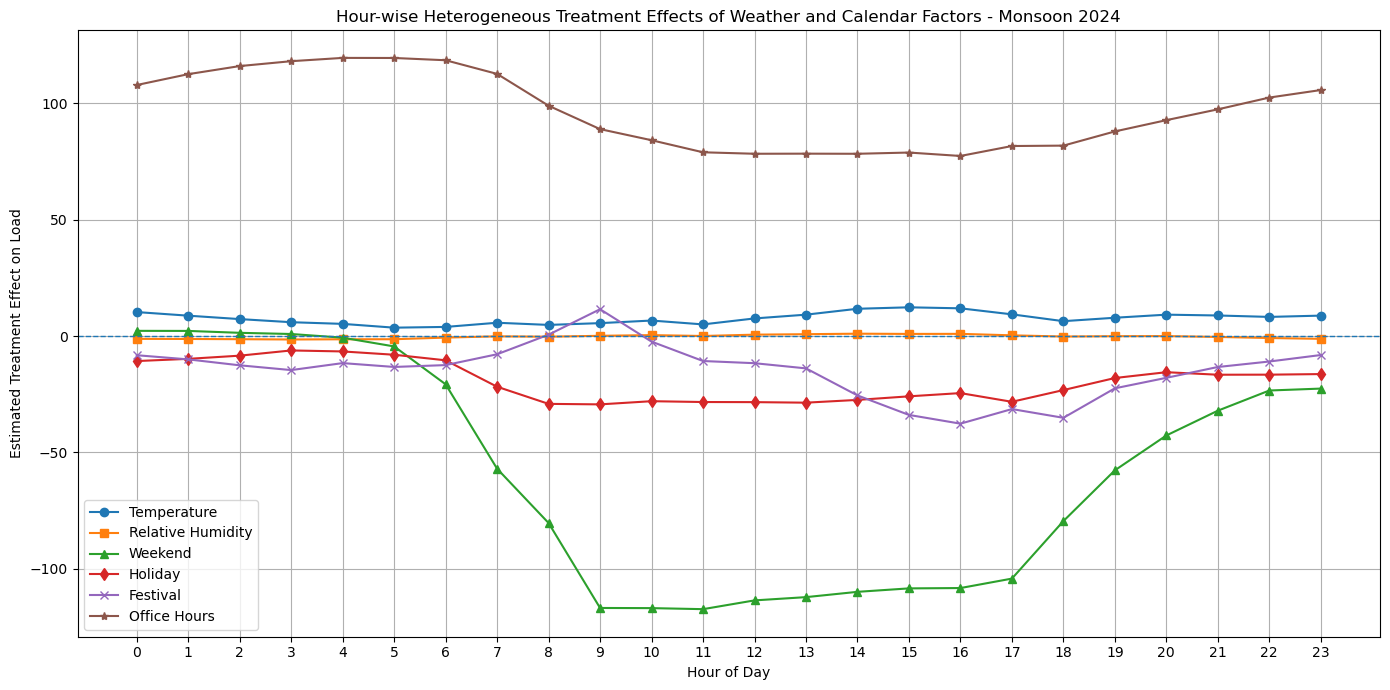

In [7]:
# =====================================================
# HOUR-WISE HETEROGENEOUS TREATMENT EFFECTS
# MONSOON 2024
# =====================================================

plot_df = pd.DataFrame({

    "hour": df["hour"],

    # Weather
    "Temperature": temp_effect,

    "Relative Humidity": rh_effect,

    # Calendar / Human Activity
    "Weekend": weekend_effect,

    "Holiday": holiday_effect,

    "Festival": festival_effect,

    "Office Hours": office_effect

})


# =====================================================
# AVERAGE EFFECT BY HOUR
# =====================================================

hour_effect = (
    plot_df
    .groupby("hour")
    .mean()
    .reset_index()
)


# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(14, 7))


# -----------------------------------------------------
# TEMPERATURE
# -----------------------------------------------------

plt.plot(
    hour_effect["hour"],
    hour_effect["Temperature"],
    marker="o",
    label="Temperature"
)


# -----------------------------------------------------
# RELATIVE HUMIDITY
# -----------------------------------------------------

plt.plot(
    hour_effect["hour"],
    hour_effect["Relative Humidity"],
    marker="s",
    label="Relative Humidity"
)


# -----------------------------------------------------
# WEEKEND
# -----------------------------------------------------

plt.plot(
    hour_effect["hour"],
    hour_effect["Weekend"],
    marker="^",
    label="Weekend"
)


# -----------------------------------------------------
# HOLIDAY
# -----------------------------------------------------

plt.plot(
    hour_effect["hour"],
    hour_effect["Holiday"],
    marker="d",
    label="Holiday"
)


# -----------------------------------------------------
# FESTIVAL
# -----------------------------------------------------

plt.plot(
    hour_effect["hour"],
    hour_effect["Festival"],
    marker="x",
    label="Festival"
)


# -----------------------------------------------------
# OFFICE HOURS
# -----------------------------------------------------

plt.plot(
    hour_effect["hour"],
    hour_effect["Office Hours"],
    marker="*",
    label="Office Hours"
)


# =====================================================
# ZERO REFERENCE LINE
# =====================================================

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)


# =====================================================
# LABELS
# =====================================================

plt.xlabel("Hour of Day")

plt.ylabel(
    "Estimated Treatment Effect on Load"
)

plt.title(
    "Hour-wise Heterogeneous Treatment Effects of Weather and Calendar Factors - Monsoon 2024"
)

plt.xticks(range(24))

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

### Summary of Causal Effects

In [8]:
!pip install econml
import pandas as pd
import numpy as np
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

# =====================================================
# Reload Dataset and initial setup (if not already in scope)
# =====================================================

# Assuming 'df' is not globally available or kernel was reset
# If df is already loaded in the environment, these lines will just re-execute
# without error but ensure 'df' exists for this cell.
df = pd.read_csv("monsoon_2024 (1).csv")
df = df.dropna().reset_index(drop=True)

# =====================================================
# Re-calculate Weather Effects (ATE & CATE)
# From cell lZmFTElZ3Y8o
# =====================================================

Y = df["wdLoad"].values
T_weather = df[["temp", "rh"]].values
X_weather = df[["hour", "weekend", "holiday", "festival", "office_hours"]].values

model_weather = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=300, random_state=42),
    model_t=MultiOutputRegressor(RandomForestRegressor(n_estimators=300, random_state=42)),
    n_estimators=500,
    min_samples_leaf=10,
    random_state=42
)
model_weather.fit(Y, T_weather, X=X_weather)

effects_weather = model_weather.const_marginal_effect(X_weather)
temp_effect = effects_weather[:, 0]
rh_effect = effects_weather[:, 1]
ate_temp = np.mean(temp_effect)
ate_rh = np.mean(rh_effect)

# =====================================================
# Re-calculate Socio-Economic / Calendar Effects (ATE & CATE)
# From cell 9HWS7hLDDjeH
# =====================================================

def estimate_binary_treatment(df_func, treatment, controls):
    Y_func = df_func["wdLoad"].values
    T_func = df_func[treatment].values
    X_func = df_func[controls].values

    model_func = CausalForestDML(
        model_y=RandomForestRegressor(n_estimators=300, random_state=42),
        model_t=RandomForestRegressor(n_estimators=300, random_state=42),
        n_estimators=500,
        min_samples_leaf=10,
        random_state=42
    )
    model_func.fit(Y_func, T_func, X=X_func)
    effects_func = model_func.effect(X_func, T0=0, T1=1)
    ate_func = np.mean(effects_func)
    inference_func = model_func.ate_inference(X_func, T0=0, T1=1)
    ci_func = inference_func.conf_int_mean()
    return model_func, effects_func, ate_func, ci_func

# Weekend
weekend_model, weekend_effect, weekend_ate, weekend_ci = \
    estimate_binary_treatment(
        df,
        "weekend",
        ["temp", "rh", "hour", "holiday", "festival", "office_hours"]
    )

# Holiday
holiday_model, holiday_effect, holiday_ate, holiday_ci = \
    estimate_binary_treatment(
        df,
        "holiday",
        ["temp", "rh", "hour", "weekend", "festival", "office_hours"]
    )

# Festival
festival_model, festival_effect, festival_ate, festival_ci = \
    estimate_binary_treatment(
        df,
        "festival",
        ["temp", "rh", "hour", "weekend", "holiday", "office_hours"]
    )

# Office Hours
office_model, office_effect, office_ate, office_ci = \
    estimate_binary_treatment(
        df,
        "office_hours",
        ["temp", "rh", "weekend", "holiday", "festival"]
    )

# =====================================================
# Re-calculate Hour-wise Heterogeneous Treatment Effects (HTE)
# From cell exhT1RpjMWLl
# =====================================================

plot_df = pd.DataFrame({
    "hour": df["hour"],
    "Temperature": temp_effect,
    "Relative Humidity": rh_effect,
    "Weekend": weekend_effect,
    "Holiday": holiday_effect,
    "Festival": festival_effect,
    "Office Hours": office_effect
})
hour_effect = plot_df.groupby("hour").mean().reset_index()


print("==============================================")
print("       SUMMARY OF CAUSAL EFFECTS")
print("==============================================")

print("\n--- Average Treatment Effects (ATE) ---")
print("\nWeather Effects:")
print(f"  Average Marginal Effect (Temperature -> Load): {ate_temp:.2f}")
print(f"  Average Marginal Effect (Humidity -> Load): {ate_rh:.2f}")

print("\nSocio-Economic / Calendar Effects:")
print(f"  Weekend -> Load: ATE={weekend_ate:.2f}, 95% CI=({weekend_ci[0]:.2f}, {weekend_ci[1]:.2f})")
print(f"  Holiday -> Load: ATE={holiday_ate:.2f}, 95% CI=({holiday_ci[0]:.2f}, {holiday_ci[1]:.2f})")
print(f"  Festival -> Load: ATE={festival_ate:.2f}, 95% CI=({festival_ci[0]:.2f}, {festival_ci[1]:.2f})")
print(f"  Office Hours -> Load: ATE={office_ate:.2f}, 95% CI=({office_ci[0]:.2f}, {office_ci[1]:.2f})")

print("\n--- Conditional Average Treatment Effects (CATE) ---")
print("\nConditional Marginal Effects for Temperature and Humidity (first 5 samples):")
display(pd.DataFrame({'temp_effect': temp_effect, 'rh_effect': rh_effect}).head())

print("\nIndividual Treatment Effects for Weekend (first 5 samples):")
display(pd.DataFrame({'weekend_effect': weekend_effect}).head())

print("\n--- Heterogeneous Treatment Effects (HTE) by Hour ---")
print("Average effect of each factor across hours:")
display(hour_effect)


FileNotFoundError: [Errno 2] No such file or directory: 'monsoon_2024 (1).csv'

In [ ]:
# ============================================================
# XAI ANALYSIS USING XGBOOST + SHAP
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap

# =====================================================
# Load Dataset (added to ensure 'df' is defined)
# =====================================================
# Debugging: List files in current directory to check for 'summer_2024 (1).csv'
!ls -l
df = pd.read_csv("monsoon_2024 (1).csv")
df = df.dropna().reset_index(drop=True)

# ------------------------------------------------------------
# 1. Prepare data
# ------------------------------------------------------------

# Features used for prediction
features = [
    "temp",
    "rh",
    "hour",
    "weekend",
    "holiday",
    "festival",
    "office_hours"
]

X_xai = df[features].copy()
y_xai = df["wdLoad"].copy()

# ------------------------------------------------------------
# 2. Train XGBoost model
# ------------------------------------------------------------

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_xai, y_xai)

# Predictions
xai_predictions = xgb_model.predict(X_xai)

print("XGBoost XAI model trained successfully.")
print("Features used:", features)


total 1144
-rw-r--r-- 1 root root 1166615 Sep  9 15:50 'monsoon_2024 (1).csv'
drwxr-xr-x 1 root root    4096 Aug 24 13:28  sample_data
XGBoost XAI model trained successfully.
Features used: ['temp', 'rh', 'hour', 'weekend', 'holiday', 'festival', 'office_hours']



Feature Importance:


,Feature,Importance
6,office_hours,0.576603
2,hour,0.194494
3,weekend,0.170654
5,festival,0.018514
0,temp,0.016324
4,holiday,0.015283
1,rh,0.008128


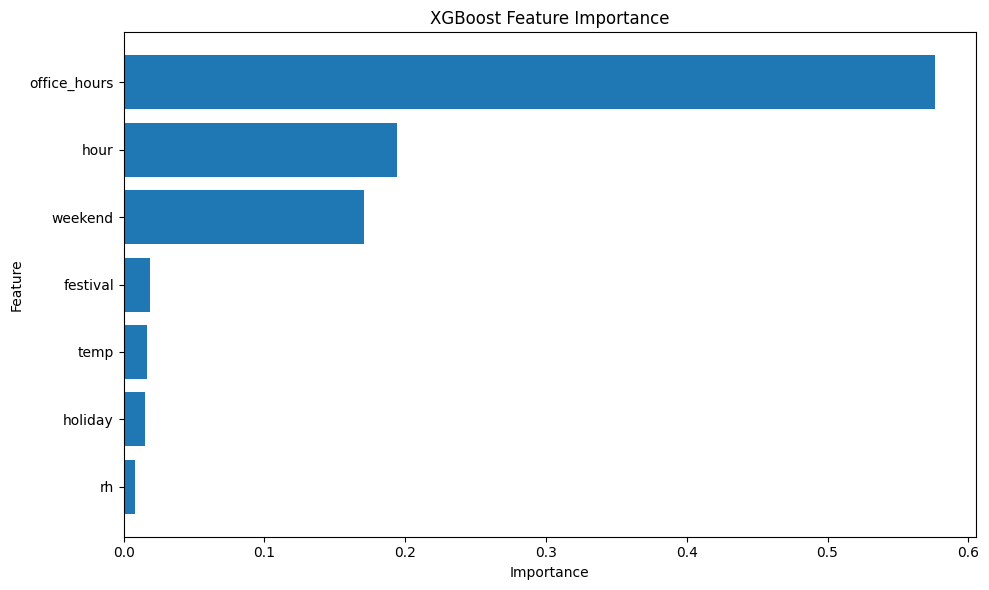

In [ ]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print("\nFeature Importance:")
display(importance)

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SHAP ANALYSIS
# ============================================================

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_xai)

print("SHAP analysis completed.")

SHAP analysis completed.


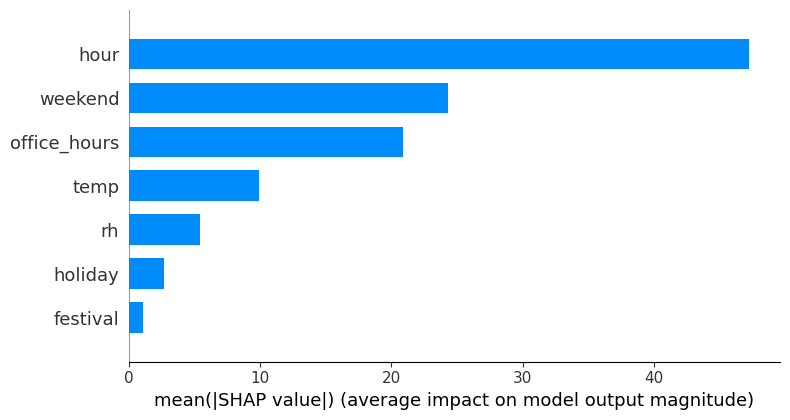

In [ ]:
# ============================================================
# GLOBAL SHAP IMPORTANCE
# ============================================================

shap.summary_plot(
    shap_values,
    X_xai,
    plot_type="bar"
)

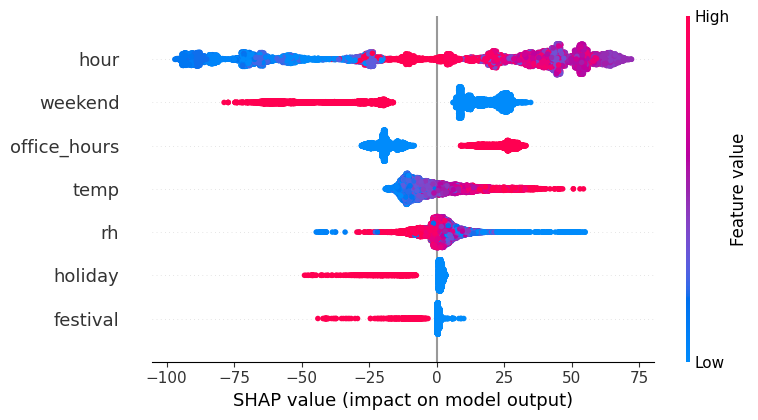

In [ ]:
# ============================================================
# SHAP BEESWARM
# ============================================================

shap.summary_plot(
    shap_values,
    X_xai
)

In [ ]:
# ============================================================
# LIME LOCAL EXPLANATION - MONSOON 2024
# Native LIME HTML visualization
# ============================================================

import numpy as np
import pandas as pd

from lime.lime_tabular import LimeTabularExplainer
from IPython.display import display, HTML


# ============================================================
# 1. FEATURES
#    Use EXACTLY the same features used for SHAP/XGBoost
# ============================================================

features = [
    "temp",
    "rh",
    "hour",
    "weekend",
    "holiday",
    "festival",
    "office_hours"
]

X_lime = df[features].copy()
y_lime = df["wdLoad"].copy()


# ============================================================
# 2. XGBOOST PREDICTION FUNCTION
# ============================================================

def predict_fn(data):
    """
    Prediction function used by LIME.
    """
    data_df = pd.DataFrame(
        data,
        columns=features
    )

    return xgb_model.predict(data_df)


# ============================================================
# 3. CREATE LIME EXPLAINER
# ============================================================

lime_explainer = LimeTabularExplainer(
    training_data=X_lime.values,
    feature_names=features,
    mode="regression",
    discretize_continuous=True,
    random_state=42
)


# ============================================================
# 4. FIND A REPRESENTATIVE OBSERVATION
# ============================================================
#
# We want a local explanation that contains:
#   - at least one positive contribution
#   - at least one negative contribution
#
# This produces the familiar LIME visualization with
# "negative" on the left and "positive" on the right.
#
# We search several observations instead of arbitrarily
# choosing the maximum-load observation.
# ============================================================

rng = np.random.RandomState(42)

candidate_indices = rng.choice(
    len(X_lime),
    size=min(300, len(X_lime)),
    replace=False
)

selected_idx = None
selected_explanation = None

for idx in candidate_indices:

    explanation = lime_explainer.explain_instance(
        X_lime.iloc[idx].values,
        predict_fn,
        num_features=2,
        num_samples=5000
    )

    contributions = [
        contribution
        for _, contribution in explanation.as_list()
    ]

    has_positive = any(c > 0 for c in contributions)
    has_negative = any(c < 0 for c in contributions)

    if has_positive and has_negative:

        selected_idx = X_lime.index[idx]
        selected_explanation = explanation
        break


# ============================================================
# 5. FALLBACK
# ============================================================
#
# If no observation with both signs is found in the first
# sample, use the highest-load observation.
# ============================================================

if selected_idx is None:

    selected_idx = y_lime.idxmax()

    selected_explanation = lime_explainer.explain_instance(
        X_lime.loc[selected_idx].values,
        predict_fn,
        num_features=2,
        num_samples=5000
    )


# ============================================================
# 6. GET ACTUAL AND PREDICTED VALUES
# ============================================================

actual_load = float(
    y_lime.loc[selected_idx]
)

predicted_load = float(
    xgb_model.predict(
        X_lime.loc[[selected_idx]]
    )[0]
)


# ============================================================
# 7. PRINT INFORMATION
# ============================================================

print("=" * 70)
print("LIME LOCAL EXPLANATION - MONSOON 2024")
print("=" * 70)

print("Observation Index :", selected_idx)
print("Actual Load       :", round(actual_load, 2))
print("Predicted Load    :", round(predicted_load, 2))

print("\nInput Features:")

display(
    X_lime.loc[[selected_idx]]
)


# ============================================================
# 8. PRINT LIME CONTRIBUTIONS
# ============================================================

print("\nLIME Local Contributions:")

for feature_condition, contribution in selected_explanation.as_list():

    direction = (
        "Positive"
        if contribution > 0
        else "Negative"
    )

    print(
        f"{feature_condition:<35} "
        f"{contribution:+.4f}   "
        f"{direction}"
    )


# ============================================================
# 9. DISPLAY NATIVE LIME HTML VISUALIZATION
# ============================================================
#
# THIS is the important change.
#
# Do NOT use:
#     as_pyplot_figure()
#
# Instead use:
#     as_html()
#
# This produces the native LIME visualization containing:
#   Predicted value
#   min/max prediction
#   positive/negative sections
#   feature conditions
# ============================================================

lime_html = selected_explanation.as_html()

display(
    HTML(lime_html)
)

LIME LOCAL EXPLANATION - MONSOON 2024
Observation Index : 6607
Actual Load       : 439.99
Predicted Load    : 448.7

Input Features:


,temp,rh,hour,weekend,holiday,festival,office_hours
6607,28.88,85.22,19,0,0,0,0



LIME Local Contributions:
weekend <= 0.00                     +58.1109   Positive
office_hours <= 0.00                -36.6511   Negative


LIME LOCAL EXPLANATION - MONSOON 2024
Observation Index : 541
Actual Load       : 621.47
Predicted Load    : 607.75

Input Features:


,temp,rh,hour,weekend,holiday,festival,office_hours
541,34.82,63.26,15,0,0,0,1



LIME Feature Contributions:
11.50 < hour <= 17.25                  60.9451   Positive
weekend <= 0.00                        59.8464   Positive
0.00 < office_hours <= 1.00            32.8368   Positive
temp > 30.10                           25.0472   Positive
holiday <= 0.00                        19.5492   Positive
rh <= 81.00                            14.5482   Positive
festival <= 0.00                       12.2905   Positive


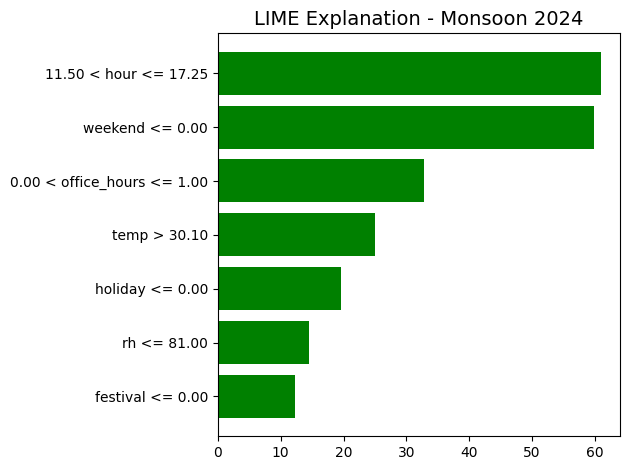

In [ ]:
# ============================================================
# LIME LOCAL EXPLANATION - MONSOON 2024
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lime.lime_tabular import LimeTabularExplainer


# ============================================================
# 1. SAME FEATURES USED FOR SHAP
# ============================================================

features = [
    "temp",
    "rh",
    "hour",
    "weekend",
    "holiday",
    "festival",
    "office_hours"
]

X_lime = df[features].copy()
y_lime = df["wdLoad"].copy()


# ============================================================
# 2. PREDICTION FUNCTION FOR XGBOOST
# ============================================================

def predict_fn(data):
    data = pd.DataFrame(data, columns=features)
    return xgb_model.predict(data)


# ============================================================
# 3. CREATE LIME EXPLAINER
# ============================================================

lime_explainer = LimeTabularExplainer(
    training_data=X_lime.values,
    feature_names=features,
    mode="regression",
    discretize_continuous=True,
    random_state=42
)


# ============================================================
# 4. SELECT A REPRESENTATIVE OBSERVATION
# ============================================================

# Select the observation having the highest actual electricity load.
# This gives a meaningful local explanation of a high-load case.

observation_idx = y_lime.idxmax()

observation = X_lime.loc[observation_idx].values


# ============================================================
# 5. GENERATE LIME EXPLANATION
# ============================================================

explanation = lime_explainer.explain_instance(
    observation,
    predict_fn,
    num_features=len(features),
    num_samples=5000
)


# ============================================================
# 6. DISPLAY OBSERVATION DETAILS
# ============================================================

actual_load = float(y_lime.loc[observation_idx])

predicted_load = float(
    xgb_model.predict(
        X_lime.loc[[observation_idx]]
    )[0]
)

print("=" * 70)
print("LIME LOCAL EXPLANATION - MONSOON 2024")
print("=" * 70)

print("Observation Index :", observation_idx)
print("Actual Load       :", round(actual_load, 2))
print("Predicted Load    :", round(predicted_load, 2))

print("\nInput Features:")
display(
    X_lime.loc[[observation_idx]]
)


# ============================================================
# 7. DISPLAY LIME CONTRIBUTIONS
# ============================================================

print("\nLIME Feature Contributions:")

for feature, contribution in explanation.as_list():

    direction = "Positive" if contribution > 0 else "Negative"

    print(
        f"{feature:<35} "
        f"{contribution:>10.4f}   "
        f"{direction}"
    )


# ============================================================
# 8. GENERATE STANDARD LIME GRAPH
# ============================================================

fig = explanation.as_pyplot_figure()

plt.title(
    "LIME Explanation - Monsoon 2024",
    fontsize=14
)

plt.tight_layout()
plt.show()

Selected Day: 2024-06-29

SINGLE-DAY HOURLY TREATMENT EFFECTS
Selected Date: 2024-06-29


,hour,Temperature,Relative Humidity,Weekend,Holiday,Festival,Office Hours
0,0,16.459871,-0.236360,-2.377520,-5.014093,-10.452950,49.083544
1,1,15.506140,-0.279138,1.414655,-4.352099,-6.618489,41.451480
2,2,11.333076,-0.889050,0.408309,-2.520928,-12.159232,32.659225
3,3,8.532555,-1.214963,6.617938,-4.391939,-9.492049,26.007986
4,4,7.519308,-1.279530,4.753934,-3.068819,-11.075777,31.872994
5,5,3.748059,-1.647773,-3.278092,-2.597204,-13.712527,40.343190
6,6,1.824464,-1.266896,-26.100138,-2.201646,-7.408074,31.661678
7,7,1.607765,-0.792007,-60.170544,-16.690869,-5.468767,23.778682
8,8,-3.492828,-1.265618,-82.878551,-23.947251,1.592980,33.176378
9,9,-5.781800,-1.428207,-116.919433,-42.886707,12.749514,26.127244


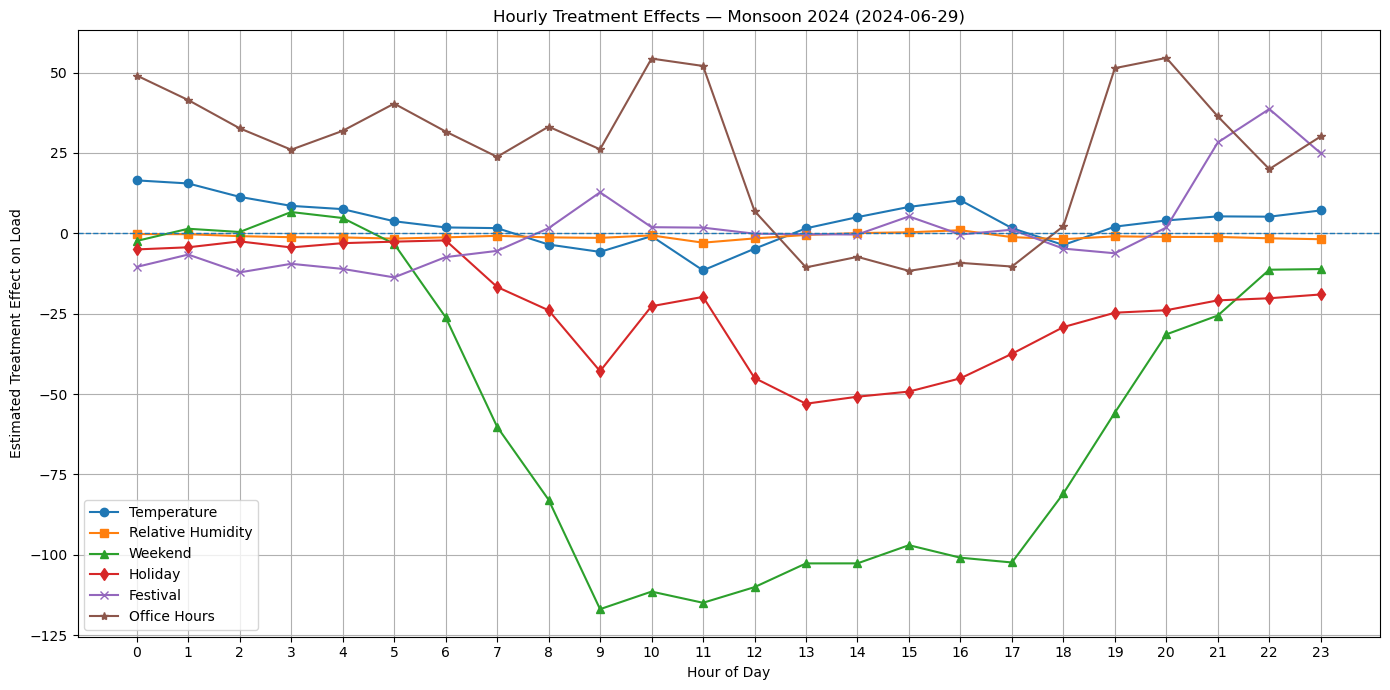

In [9]:
# =====================================================
# TREATMENT EFFECTS FOR A SINGLE DAY
# MONSOON 2024
# =====================================================

# Convert datetime to date
df["date"] = pd.to_datetime(df["datetime"]).dt.date


# -----------------------------------------------------
# SELECT ONE RANDOM DAY
# -----------------------------------------------------

selected_date = np.random.choice(
    df["date"].unique()
)

print("Selected Day:", selected_date)


# -----------------------------------------------------
# CREATE TREATMENT-EFFECT DATAFRAME
# -----------------------------------------------------

plot_df = pd.DataFrame({

    "date": df["date"],
    "hour": df["hour"],

    # Weather treatment effects
    "Temperature": temp_effect,
    "Relative Humidity": rh_effect,

    # Calendar / human activity treatment effects
    "Weekend": weekend_effect,
    "Holiday": holiday_effect,
    "Festival": festival_effect,
    "Office Hours": office_effect
})


# -----------------------------------------------------
# FILTER ONLY THE SELECTED DAY
# -----------------------------------------------------

day_df = plot_df[
    plot_df["date"] == selected_date
].copy()


# -----------------------------------------------------
# HOURLY TREATMENT EFFECT
# -----------------------------------------------------
#
# The dataset has 15-minute observations.
#
# Therefore:
# 4 observations = 1 hour
#
# We average those observations ONLY within
# the selected day and hour.
#
# We DO NOT average across different days.
# -----------------------------------------------------

hour_effect_day = (
    day_df
    .groupby("hour")
    [
        [
            "Temperature",
            "Relative Humidity",
            "Weekend",
            "Holiday",
            "Festival",
            "Office Hours"
        ]
    ]
    .mean()
    .reset_index()
)


# =====================================================
# DISPLAY RESULTS
# =====================================================

print("\n==============================================")
print("SINGLE-DAY HOURLY TREATMENT EFFECTS")
print("==============================================")

print("Selected Date:", selected_date)

display(hour_effect_day)


# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(14, 7))


# -----------------------------------------------------
# TEMPERATURE
# -----------------------------------------------------

plt.plot(
    hour_effect_day["hour"],
    hour_effect_day["Temperature"],
    marker="o",
    label="Temperature"
)


# -----------------------------------------------------
# RELATIVE HUMIDITY
# -----------------------------------------------------

plt.plot(
    hour_effect_day["hour"],
    hour_effect_day["Relative Humidity"],
    marker="s",
    label="Relative Humidity"
)


# -----------------------------------------------------
# WEEKEND
# -----------------------------------------------------

plt.plot(
    hour_effect_day["hour"],
    hour_effect_day["Weekend"],
    marker="^",
    label="Weekend"
)


# -----------------------------------------------------
# HOLIDAY
# -----------------------------------------------------

plt.plot(
    hour_effect_day["hour"],
    hour_effect_day["Holiday"],
    marker="d",
    label="Holiday"
)


# -----------------------------------------------------
# FESTIVAL
# -----------------------------------------------------

plt.plot(
    hour_effect_day["hour"],
    hour_effect_day["Festival"],
    marker="x",
    label="Festival"
)


# -----------------------------------------------------
# OFFICE HOURS
# -----------------------------------------------------

plt.plot(
    hour_effect_day["hour"],
    hour_effect_day["Office Hours"],
    marker="*",
    label="Office Hours"
)


# -----------------------------------------------------
# ZERO REFERENCE
# -----------------------------------------------------

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)


# -----------------------------------------------------
# LABELS
# -----------------------------------------------------

plt.xlabel("Hour of Day")

plt.ylabel(
    "Estimated Treatment Effect on Load"
)

plt.title(
    f"Hourly Treatment Effects — Monsoon 2024 ({selected_date})"
)

plt.xticks(range(24))

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()